# Skin Guard: Environmental Threshold Analysis (Data-Driven)
This notebook performs a binning (quantile) analysis on skin degradation factors in order to determine numerical thresholds that trigger "vigilance" alerts.
We aim to answer:
1. **At what Temperature Shock does water loss / oil gain become severe?**
2. **At what Humidity Shock do we see critical changes?**
3. **What are the risk thresholds for Cloud Cover and UV Index?**

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load data and replicate the merging logic from eda_skin.ipynb
skin_df = pd.read_csv('../data/skin-monitor.csv')
skin_df.columns = skin_df.columns.str.strip()
skin_df['GoOut'] = skin_df['GoOut'].str.lower()
skin_df['datetime'] = pd.to_datetime('2026/' + skin_df['date'] + ' ' + skin_df['time'], format='%Y/%d/%m %H:%M').dt.tz_localize('UTC')

with open('../data/indoor_data.json', 'r') as f:
    indoor_raw = json.load(f)
indoor_records = [{'datetime': pd.to_datetime(e['time']), 'in_temp': e['values']['temperature'], 'in_humidity': e['values']['humidity']} for e in indoor_raw]
indoor_df = pd.DataFrame(indoor_records)

with open('../data/tomorrow_recent_data.json', 'r') as f:
    outdoor_raw = json.load(f)
outdoor_records = []
for entry in outdoor_raw:
    row = entry['Values'].copy()
    row['datetime'] = pd.to_datetime(entry['time'])
    outdoor_records.append(row)
outdoor_df = pd.DataFrame(outdoor_records)
outdoor_features = ['temperature', 'humidity', 'uvIndex', 'windSpeed', 'cloudCover', 'dewPoint']

records = []
for dt, group in skin_df.groupby(skin_df['datetime'].dt.date):
    before = group[group['GoOut'] == 'before']
    after = group[group['GoOut'] == 'after']
    
    did_go_out = len(after) > 0
    if not did_go_out:
        continue
        
    record = {'date': dt}
    time_out, time_in = None, None
    if not before.empty:
        b_row = before.iloc[-1]
        record['before_water'] = b_row['WATER']
        record['before_oil'] = b_row['OIL']
        time_out = b_row['datetime']
    else:
        record['before_water'] = np.nan; record['before_oil'] = np.nan
        
    if not after.empty:
        a_row = after.iloc[-1]
        record['after_water'] = a_row['WATER']
        record['after_oil'] = a_row['OIL']
        time_in = a_row['datetime']
    else:
        record['after_water'] = np.nan; record['after_oil'] = np.nan
        
    record['water_diff'] = record['after_water'] - record['before_water']
    record['oil_diff'] = record['after_oil'] - record['before_oil']

    if time_out is not None:
        start_of_day = pd.to_datetime(f"{dt} 00:00:00").tz_localize('UTC')
        indoor_slice = indoor_df[(indoor_df['datetime'] >= start_of_day) & (indoor_df['datetime'] <= time_out)]
        if not indoor_slice.empty:
            record['in_temp_mean'] = indoor_slice['in_temp'].mean()
            record['in_humidity_mean'] = indoor_slice['in_humidity'].mean()
            
    if time_out is not None and time_in is not None:
        out_start = time_out - pd.Timedelta(hours=1)
        out_end = time_in + pd.Timedelta(hours=1)
        outdoor_slice = outdoor_df[(outdoor_df['datetime'] >= out_start) & (outdoor_df['datetime'] <= out_end)]
        if not outdoor_slice.empty:
            for feat in outdoor_features:
                record[f'out_{feat}_mean'] = outdoor_slice[feat].mean()
                
    records.append(record)

df = pd.DataFrame(records)
df['temp_diff_out_in'] = df['out_temperature_mean'] - df['in_temp_mean']
df['humidity_diff_out_in'] = df['out_humidity_mean'] - df['in_humidity_mean']
df.dropna(subset=['water_diff', 'oil_diff'], inplace=True)
df.head()

,date,before_water,before_oil,after_water,after_oil,water_diff,oil_diff,in_temp_mean,in_humidity_mean,out_temperature_mean,out_humidity_mean,out_uvIndex_mean,out_windSpeed_mean,out_cloudCover_mean,out_dewPoint_mean,temp_diff_out_in,humidity_diff_out_in
1,2026-03-03,25.0,25.0,27,26,2.0,1.0,22.625000,61.875000,11.392308,70.923077,0.384615,1.115385,21.769231,6.223077,-11.232692,9.048077
2,2026-03-04,28.0,26.0,22,23,-6.0,-3.0,22.642857,61.285714,9.490000,88.000000,0.909091,0.890909,33.230000,7.545455,-13.152857,26.714286
3,2026-03-05,27.0,26.0,23,24,-4.0,-2.0,22.000000,62.058824,15.315385,64.538462,0.769231,0.646154,27.986154,8.384615,-6.684615,2.479638
4,2026-03-08,30.0,27.0,24,24,-6.0,-3.0,22.040000,68.320000,9.201818,90.000000,0.363636,0.554545,60.831818,7.654545,-12.838182,21.680000
5,2026-03-09,30.0,27.0,31,28,1.0,1.0,22.277778,67.777778,11.541429,85.642857,0.428571,0.264286,64.351429,9.157143,-10.736349,17.865079


/var/folders/9s/lbf5r70j6_1_c29ygw008t_m0000gn/T/ipykernel_84161/2228223473.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  thermal_agg = df.groupby('temp_shock_bin')[['water_diff', 'oil_diff']].mean()


,water_diff,oil_diff
temp_shock_bin,,
< -10°C (Extreme Cold Shock),-2.571429,-1.142857
-10°C to -5°C (Cold Shock),-5.666667,-3.666667
-5°C to 0°C (Mild Cooling),NaN,NaN
0°C to 5°C (Mild Warming),NaN,NaN
> 5°C (Hot Shock),NaN,NaN


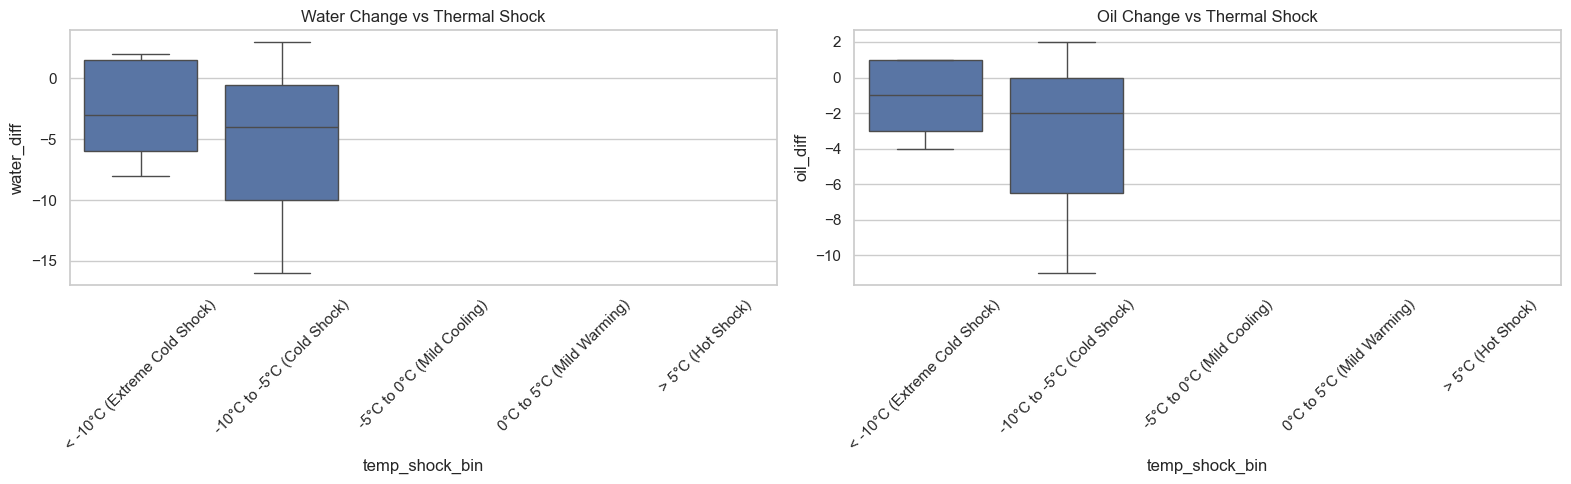

In [2]:
# 1. Thermal Shock Threshold (Temperature Diff Binning)
# Bin temp_diff_out_in to see at what temperature difference we see significant damage
bins = [-np.inf, -10, -5, 0, 5, np.inf]
labels = ["< -10°C (Extreme Cold Shock)", "-10°C to -5°C (Cold Shock)", "-5°C to 0°C (Mild Cooling)", "0°C to 5°C (Mild Warming)", "> 5°C (Hot Shock)"]
df['temp_shock_bin'] = pd.cut(df['temp_diff_out_in'], bins=bins, labels=labels)

# Calculate mean water loss and mean oil increase per bin
thermal_agg = df.groupby('temp_shock_bin')[['water_diff', 'oil_diff']].mean()
display(thermal_agg)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(data=df, x='temp_shock_bin', y='water_diff', ax=ax1)
ax1.set_title("Water Change vs Thermal Shock")
ax1.tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='temp_shock_bin', y='oil_diff', ax=ax2)
ax2.set_title("Oil Change vs Thermal Shock")
ax2.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

/var/folders/9s/lbf5r70j6_1_c29ygw008t_m0000gn/T/ipykernel_84161/199587393.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  humid_agg = df.groupby('humid_shock_bin')[['water_diff', 'oil_diff']].mean()


,water_diff,oil_diff
humid_shock_bin,,
< -5% (Drying),NaN,NaN
-5% to 5% (Stable),-5.666667,-3.666667
5% to 15% (Humid),2.000000,1.000000
> 15% (Very Humid),-3.333333,-1.500000


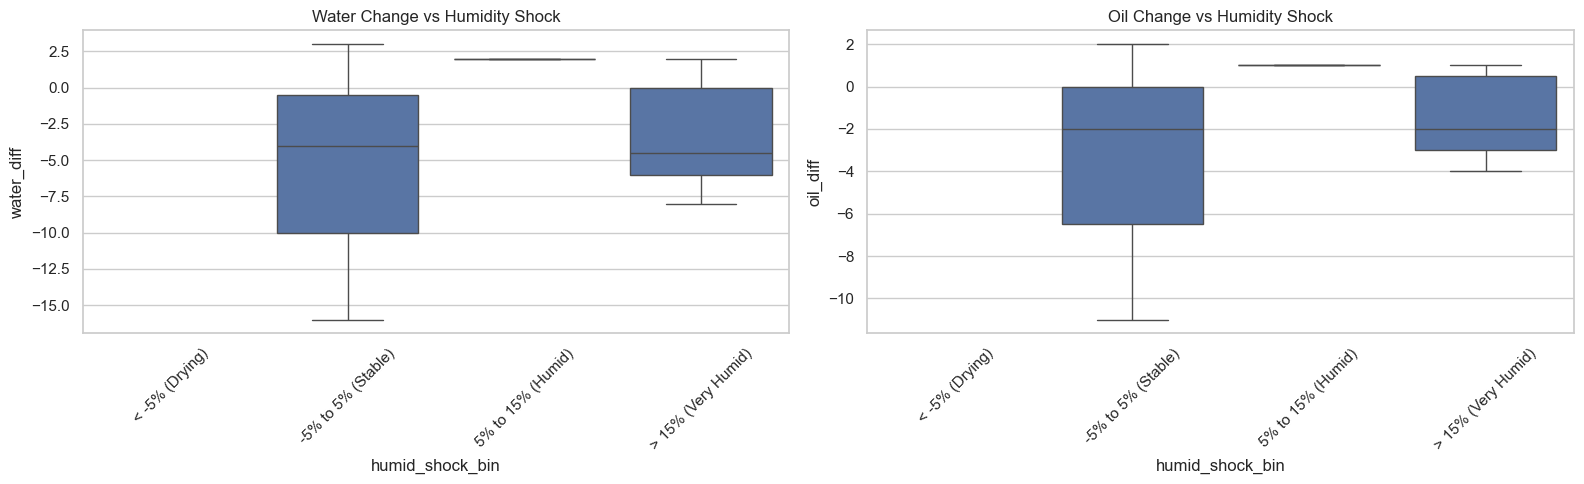

In [3]:
# 2. Humidity Shock Threshold
# Bin humidity diff
humid_bins = [-np.inf, -5, 5, 15, np.inf]
humid_labels = ["< -5% (Drying)", "-5% to 5% (Stable)", "5% to 15% (Humid)", "> 15% (Very Humid)"]
df['humid_shock_bin'] = pd.cut(df['humidity_diff_out_in'], bins=humid_bins, labels=humid_labels)

humid_agg = df.groupby('humid_shock_bin')[['water_diff', 'oil_diff']].mean()
display(humid_agg)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(data=df, x='humid_shock_bin', y='water_diff', ax=ax1)
ax1.tick_params(axis='x', rotation=45)
ax1.set_title("Water Change vs Humidity Shock")
sns.boxplot(data=df, x='humid_shock_bin', y='oil_diff', ax=ax2)
ax2.tick_params(axis='x', rotation=45)
ax2.set_title("Oil Change vs Humidity Shock")
plt.tight_layout()
plt.show()

In [4]:
# 3. Pure Outdoor Threats (UV Index & Cloud Cover)

# UV Index Thresholds
df['uv_bin'] = pd.cut(df['out_uvIndex_mean'], bins=[-np.inf, 2, 5, np.inf], labels=["0-2 (Low)", "3-5 (Moderate)", "> 5 (High)"])
display(df.groupby('uv_bin')[['oil_diff']].mean())

# Cloud Cover Thresholds
df['cloud_bin'] = pd.cut(df['out_cloudCover_mean'], bins=[-np.inf, 30, 70, np.inf], labels=["< 30% (Clear)", "30-70% (Partial)", "> 70% (Overcast)"])
display(df.groupby('cloud_bin')[['water_diff']].mean())

/var/folders/9s/lbf5r70j6_1_c29ygw008t_m0000gn/T/ipykernel_84161/58255845.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(df.groupby('uv_bin')[['oil_diff']].mean())


,oil_diff
uv_bin,
0-2 (Low),-1.9
3-5 (Moderate),NaN
> 5 (High),NaN


/var/folders/9s/lbf5r70j6_1_c29ygw008t_m0000gn/T/ipykernel_84161/58255845.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(df.groupby('cloud_bin')[['water_diff']].mean())


,water_diff
cloud_bin,
< 30% (Clear),0.333333
30-70% (Partial),-2.250000
> 70% (Overcast),-9.000000
